# Customer Segmentation Analysis

## Project Objective

The objective of this project is to identify distinct customer groups using the K-Means clustering algorithm based on annual income and spending behavior.

The insights generated from this analysis can help businesses design targeted marketing strategies, improve customer retention, and optimize promotional campaigns.

In [34]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib as mlb
import matplotlib.pyplot as plt
import seaborn as sns
#sns.set_palette("pastel")

import warnings
warnings.filterwarnings('ignore')

### Data Loading

In [35]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [37]:
print(df.columns)
print(df.index)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
RangeIndex(start=0, stop=200, step=1)


## Dataset Overview

The dataset contains demographic and spending information for mall customers.

Features include:

- Customer ID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1–100)

These variables are used to understand customer behavior and identify meaningful customer segments.

### Data Profiling

In [38]:
# checking for data Shape
df.shape

(200, 5)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [40]:
# Checking for duplicate rows
df.duplicated().sum()

np.int64(0)

In [41]:
# Checking for null values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [42]:
# checking for data statistics
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Data Cleaning Summary

The dataset was examined for missing values, duplicate records, and inconsistencies.

No missing values or duplicate records were identified; therefore, no additional data cleaning was required before analysis.-- the data has no vulnerabilities hence no cleaning was required

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand customer demographics, spending patterns, and relationships between variables before applying clustering techniques.

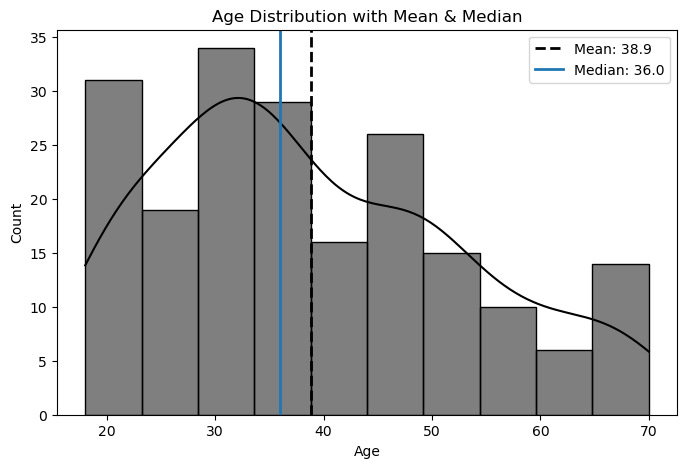

In [43]:
# Distribution of Age
plt.figure(figsize = (8,5), dpi = 100)

mean_age = df['Age'].mean()
median_age = df['Age'].median()

sns.histplot(data=df, x='Age', bins=10, kde=True, color = 'black')

# Mean line
plt.axvline(mean_age, linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}', color = 'black')

# Median line
plt.axvline(median_age, linestyle='-', linewidth=2, label=f'Median: {median_age:.1f}')

plt.legend()
plt.title("Age Distribution with Mean & Median")

plt.savefig("Age Distribution.png", dpi = 300,bbox_inches='tight')
plt.show()


“The age distribution is positively skewed, with the mean (38.9) higher than the median (36), indicating the presence of older customers pulling the average upward. However, the median suggests that the typical customer base falls in the mid-30s age group, confirming that the customer base is primarily composed of young to middle-aged adults.”

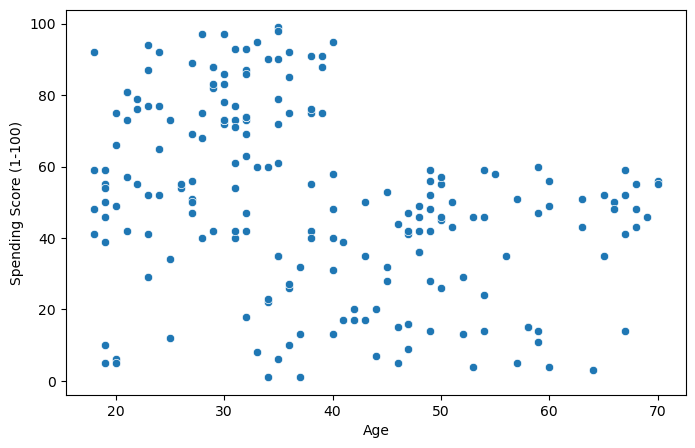

In [44]:
# Age vs Spending Score (1-100)
plt.figure(figsize = (8,5), dpi = 100)
sns.scatterplot(x=df["Age"], y=df["Spending Score (1-100)"])
plt.show()

The scatter plot shows no strong linear relationship between age and spending score. However, younger customers (18–40) tend to have higher spending scores, while older customers generally exhibit lower spending behavior. The presence of scattered clusters suggests distinct customer segments, making this dataset suitable for clustering techniques like K-Means.

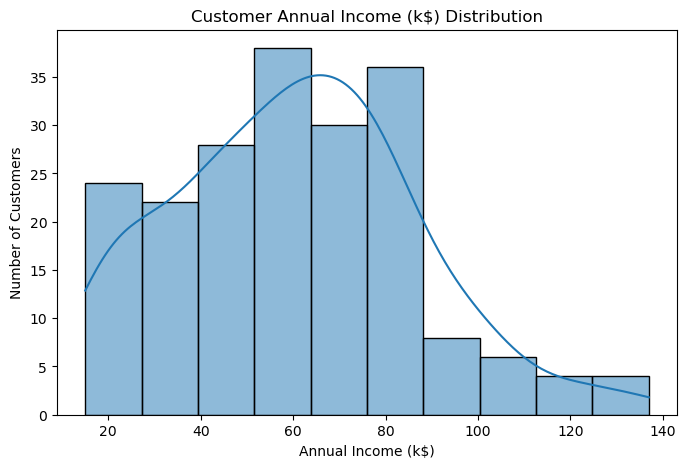

In [45]:
# Distribution of Annual Income (k$)
plt.figure(figsize = (8,5), dpi = 100)
sns.histplot(df['Annual Income (k$)'], bins=10, kde = True)
plt.title("Customer Annual Income (k$) Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")
plt.show()

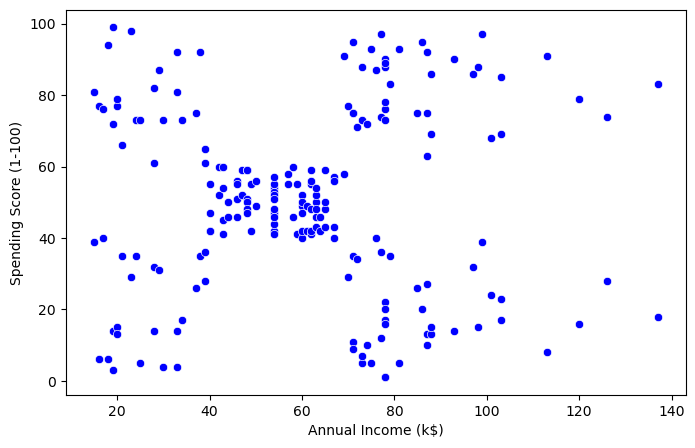

In [46]:
# Annual Income (k$) vs Spending Score (1-100)
plt.figure(figsize = (8,5), dpi = 100)
sns.scatterplot(x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], color = 'b')
plt.show()

“The scatter plot of annual income vs spending score reveals clear clustering patterns, indicating the presence of distinct customer segments. These include high-income high-spending customers (premium segment), high-income low-spending customers (potential targets), and low-income high-spending customers (impulsive buyers). This natural grouping suggests that clustering techniques like K-Means are appropriate for segmenting customers.”

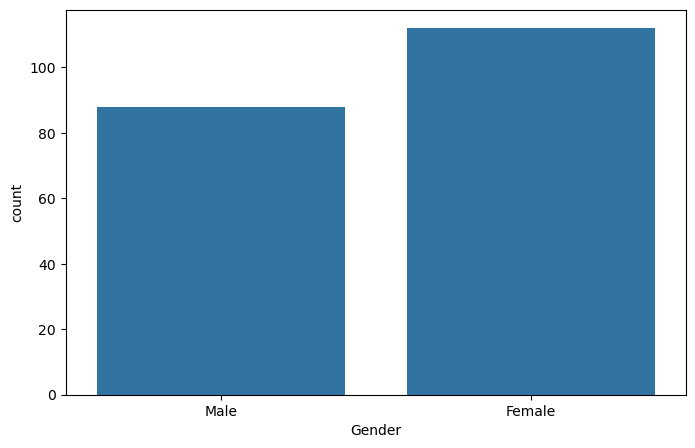

In [47]:
# Gender Distribution
plt.figure(figsize = (8,5), dpi = 100)
sns.countplot(x=df["Gender"])
plt.show()

The number of female customers is slightly higher than males.

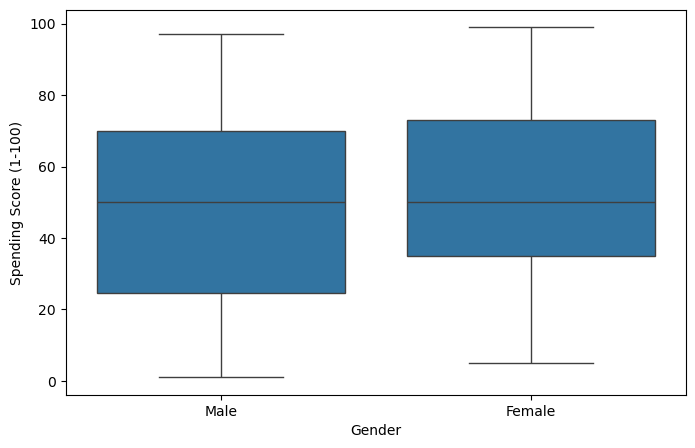

In [48]:
# Gender vs Spending Score (1-100)
plt.figure(figsize = (8,5), dpi = 100)
sns.boxplot(x=df["Gender"], y=df["Spending Score (1-100)"])
plt.show()

Although the average spending Score for both males and females is almost the same, females customers are on higher range of spending than males.

In [49]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

Explored demographic and economic variables including age, income, and gender. While income showed meaningful patterns with spending behavior, gender had limited impact on segmentation, so clustering was performed using numerical features only.

In [50]:
df['Cluster'] = df['Cluster'] + 1
df.Cluster.unique()

array([5, 3, 1, 2, 4], dtype=int32)

In [51]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,5
1,2,Male,21,15,81,3
2,3,Female,20,16,6,5
3,4,Female,23,16,77,3
4,5,Female,31,17,40,5


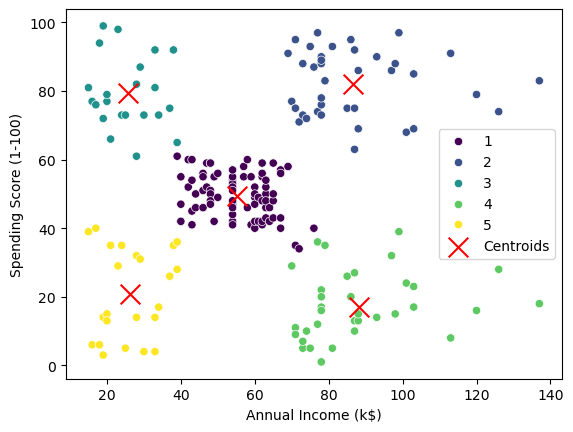

In [52]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='viridis'
)
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    marker='x',
    label='Centroids'
)

plt.legend()
#plt.savefig("clustered Annual Income vs Spending score", dpi = 300, bbox_inches ='tight' )

## Customer Segmentation using K-Means

K-Means clustering was selected because it is an unsupervised machine learning algorithm that groups customers based on similarity.

The model was trained using:

- Annual Income (k$)
- Spending Score (1–100)

These variables provide a meaningful representation of customer purchasing behaviour.

In [53]:
conditions = [
    (df["Cluster"] == 1),
    (df["Cluster"] == 2),
    (df["Cluster"] == 3),
    (df["Cluster"] == 4),
    (df["Cluster"] == 5),
    
]
choices = ["Mid Value Customers","High Value Customers","Impulse Buyers","Potential Customers","Low Value Customers"]
df["Segment"] = np.select(conditions, choices,default = 'None')


In [54]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,5,Low Value Customers
1,2,Male,21,15,81,3,Impulse Buyers
2,3,Female,20,16,6,5,Low Value Customers
3,4,Female,23,16,77,3,Impulse Buyers
4,5,Female,31,17,40,5,Low Value Customers


In [59]:
df.to_csv('../data/Mall_Customers_Segmented.csv', index=False)

## 📊 Customer Segmentation Insights

### Cluster 1: Mid Value Customers
- Income: 40–60k  
- Spending Score: 40–60  

**Insight:**  
These customers show moderate purchasing behavior and contribute steady revenue.

**Business Strategy:**  
- Offer loyalty programs  
- Encourage higher spending through targeted promotions  

### Cluster 2: High Value Customers (VIP Customers ⭐)
- Income: ~70–140k
- Spending Score: ~70–100
  
**Insight:**
Most valuable segment
Already spending heavily → strong brand affinity

**Business Strategy:**
- Premium memberships
- Exclusive offers / early access
- Personalized marketing
  
👉 This is your target retention group

### Cluster 3: Impulse Buyers
- Income: ~15–40k
- Spending Score: ~70–100
  
**Insight:**
Spend a lot despite lower income
Likely impulsive or trend-driven buyers

**Business Strategy:**
- Flash sales
- Discounts
- Influencer / trend-based marketing

👉 Good for short-term revenue boosts

### Cluster 4: Potential Customers ⭐
- Income: ~70–140k
- Spending Score: ~0–40
  
**Insight:**
High earning but not spending much
Huge untapped potential

**Business Strategy:**
- Personalized campaigns
- Product recommendations
- Highlight value / benefits

👉 These are your biggest opportunity customers

### Cluster 5: Low Value Customers
- Income: ~15–40k
- Spending Score: ~0–40
  
**Insight:**
Budget-conscious customers
Low contribution to revenue

**Business Strategy:**
- Focus on affordable products
- Avoid heavy marketing spend here

👉 Not a priority segment

## 🎯 Final Business Insights

- High Income, High Spending customers are the most valuable and should be retained.
- High Income, Low Spending score customers represent untapped potential.
- Low Income segments should be targeted with budget-friendly strategies.

**Recommendation:**  
Focus marketing efforts on converting high-income low-spending customers while maintaining loyalty of High Value customers.

## Explore the Complete Project

This notebook presents the exploratory data analysis and customer segmentation workflow.

For the complete end-to-end project:

- 📊 Power BI Dashboard – Interactive visualizations and KPI reporting.
- 💻 SQL Analysis – Business insights derived from the customer segments.
- 🌐 Streamlit Application – Interactive exploration of customer segments using filters and visualizations.